In [26]:
import numpy as np
import pandas as pd
import warnings
from sklearn.exceptions import DataConversionWarning
from sklearn.preprocessing import RobustScaler
from dowhy import CausalModel
import graphviz
from IPython.display import display

warnings.filterwarnings("ignore", category=DataConversionWarning)


In [27]:
df = pd.read_csv("alerts_with_category_and_apk_size_updated_cryptoguard.csv")
df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()

df["verdict"] = df["verdict"].astype(int)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)

download_order = [
    "<100","100-500","500-1k","1k-5k","5k-10k","10k-50k",
    "50k-100k","100k-500k","500k-1M","1M-5M",">5M"
]
ord_map = {c:i for i,c in enumerate(download_order)}
df["app_popularity_encoded"] = df["apk_category"].map(ord_map)
df = df.dropna(subset=["app_popularity_encoded"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

print("Rows:", len(df))
print("Popularity counts:\n", df["apk_category"].value_counts().reindex(download_order, fill_value=0))
print("is_third_party counts:\n", df["is_third_party"].value_counts())


Rows: 15268
Popularity counts:
 apk_category
<100         1791
100-500      1373
500-1k       1290
1k-5k        1310
5k-10k       1162
10k-50k      1122
50k-100k     1103
100k-500k    1889
500k-1M      1810
1M-5M        1115
>5M          1303
Name: count, dtype: int64
is_third_party counts:
 is_third_party
1    13943
0     1325
Name: count, dtype: int64


In [28]:
refutation_methods = [
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter",
]

baseline_bucket = "<100"
baseline_code = ord_map[baseline_bucket]

results = []


In [29]:
def balance_bucket_pair_bootstrap(df_sub, bucket_col, baseline_code, treated_code,  random_state=42):
    base = df_sub[df_sub[bucket_col] == baseline_code]
    trt  = df_sub[df_sub[bucket_col] == treated_code]

    n_base = len(base)
    n_trt  = len(trt)

    base_bal = base.copy()

    if n_trt >= n_base:
        trt_bal = trt.sample(n=n_base, replace=False, random_state=random_state)
    else:
        trt_bal = trt.sample(n=n_base, replace=True,  random_state=random_state)

    out = pd.concat([base_bal, trt_bal], axis=0)
    out = out.sample(frac=1, random_state=random_state).reset_index(drop=True)


    return out


In [30]:
def generate_causal_graph():
    causal_graph = """
    digraph {
        combined -> verdict;
        is_third_party -> combined;
        is_third_party -> verdict;
        apk_size_scaled -> combined;
        is_third_party -> apk_size_scaled;
    }
    """

    return causal_graph

def estimate_causal_effect(df_sub, causal_graph):
    model = CausalModel(
        data=df_sub,
        treatment="combined",
        outcome="verdict",
        graph=causal_graph.replace("\n", " "),
        common_causes=["is_third_party"]
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_matching",
        target_units="ate",
        confidence_intervals='bootstrap',
        method_params={
            "num_simulations": 300,
            "sample_size_fraction": 1.0,
            "confidence_level": 0.95,
        },
    )
    
    return model,identified_estimand,estimate


In [31]:
from dowhy import CausalModel
import dowhy.causal_estimators.linear_regression_estimator as lin

def mediation_graph():
    return """
    digraph {
        combined -> apk_size_scaled;
        combined -> verdict;
        apk_size_scaled -> verdict;
        is_third_party -> apk_size_scaled;
        is_third_party -> combined;
        is_third_party -> verdict;
    }
    """

def estimate_nde_nie(df_sub):
    model = CausalModel(
        data=df_sub,
        treatment="combined",
        outcome="verdict",
        graph=mediation_graph().replace("\n", " "),
        missing_nodes_as_confounders=True
    )

    
    estimand_nde = model.identify_effect(estimand_type="nonparametric-nde",
                                        proceed_when_unidentifiable=True)
    estimand_nie = model.identify_effect(estimand_type="nonparametric-nie",
                                        proceed_when_unidentifiable=True)

    nde = model.estimate_effect(
        estimand_nde,
        method_name="mediation.two_stage_regression",
        method_params={
            "first_stage_model": lin.LinearRegressionEstimator,
            "second_stage_model": lin.LinearRegressionEstimator,
        }
    )
    nie = model.estimate_effect(
        estimand_nie,
        method_name="mediation.two_stage_regression",
        method_params={
            "first_stage_model": lin.LinearRegressionEstimator,
            "second_stage_model": lin.LinearRegressionEstimator,
        }
    )

    # print("NDE:", nde.value)
    # print("NIE:", nie.value)
    return nde, nie



------------ 100-500 vs <100 ------------
Counts: {1: 3582, 0: 1791}
NDE: 0.01284039758500426  || NIE: -0.012840397960144235 

Estimated ATE: -0.17048203982877347
95% CI: (np.float64(-0.8401265587195235), np.float64(0.16080402010050254))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.17048203982877347
New effect:-0.17048203982877344
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.17048203982877347
New effect:0.011426577331099943
p value:0.87


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.17048203982877347
New effect:0.02640414146114472
p value:0.55


------------ 500-1k vs <100 ------------
Counts: {1: 3582, 0: 1791}
NDE: 0.009213606775622411  || NIE: -0.009213607484335943 

Estimated ATE: -0.23096966313046716
95% CI: (np.float64(-0.9597989949748744), np.float64(0.04355108877721939))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated eff

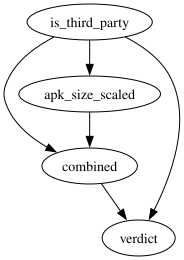

In [32]:
for bucket in download_order:
    if bucket == baseline_bucket:
        continue

    k = ord_map[bucket]

    df_sub = df[df["app_popularity_encoded"].isin([baseline_code, k])].copy()
    df_sub = balance_bucket_pair_bootstrap( df_sub,"app_popularity_encoded", baseline_code, k, random_state=100)

    df_sub["treatment_app_popularity_bucket"] = (df_sub["app_popularity_encoded"] == k).astype(int)
    

    df_all = df_sub.copy()
    df_all["combined"] = 1
    df_baseline = df_sub[df_sub["treatment_app_popularity_bucket"] == 0].copy()
    df_baseline["combined"] = 0
    df_final = pd.concat([df_all, df_baseline], ignore_index=True)
    df_sub = df_final.copy()

    nde, nie = estimate_nde_nie(df_sub)
    
    print("\n" + "-"*12 + f" {bucket} vs {baseline_bucket} " + "-"*12)
    print("Counts:", df_sub["combined"].value_counts().to_dict())
    print("NDE:", nde.value, " || NIE:", nie.value,"\n")


    causal_graph = generate_causal_graph()

    model, identified_estimand, estimate = estimate_causal_effect(df_sub, causal_graph)

    print("Estimated ATE:", estimate.value)
    try:
        print("95% CI:", estimate.get_confidence_intervals())
    except Exception:
        pass

    results.append({
        "bucket": bucket,
        "ATE_vs_<100": float(estimate.value)
    })

    for method in refutation_methods:
        if method == "placebo_treatment_refuter":
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method,
                placebo_type="permute",
                num_simulations=200
            )
        elif method == "data_subset_refuter":
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method,
                subset_fraction=0.8,
                num_simulations=200
            )
        else:
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method
            )
        print(f"\nRefuter: {method}\n", ref)

g = graphviz.Source(causal_graph)
display(g)

In [33]:
results_df = pd.DataFrame(results)
print("\n\n","-"*25 + "Summary: Bucket-specific ATE vs <100" + "-"*25)
print(results_df)




 -------------------------Summary: Bucket-specific ATE vs <100-------------------------
      bucket  ATE_vs_<100
0    100-500    -0.170482
1     500-1k    -0.230970
2      1k-5k    -0.239531
3     5k-10k    -0.236925
4    10k-50k    -0.502513
5   50k-100k    -0.183696
6  100k-500k    -0.217942
7    500k-1M    -0.219058
8      1M-5M    -0.237670
9        >5M    -0.230039
